In [6]:
import scanpy as sc
import numpy as np
import pandas as pd
import anndata as ad
import glob
import seaborn as sns
from scipy.stats import median_abs_deviation
sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()
sc.settings.set_figure_params(dpi=80, facecolor='white')

In [ ]:
root_path = '/mnt/backup/flamingo/crc/result/hdf5/'

hdf5_files = glob.glob(root_path+'*.hdf5')

basename = lambda x: x.split("/")[-1].split('.')[0]
basenames = [x.split("/")[-1].split('.')[0] for x in hdf5_files]
csv_files = [root_path + x +'.csv' for x in basenames]

metadata_list = [pd.read_csv(x) for x in csv_files]
adata_read_list = [sc.read_10x_h5(x) for x in hdf5_files]

basenames

In [14]:
def add_meta(adata,metadata):
    adata.obs = metadata
    return adata

print(1)
adata_list = [add_meta(adata,metadata) for adata,metadata in zip(adata_read_list,metadata_list) if set(add_meta(adata,metadata).obs['histological_type']) == {'Adenocarcinoma'}]
print(2)
adata_concat = ad.concat(adata_list, index_unique="_")
print(3)
adata_concat.var_names_make_unique()
print(4)
adata_concat

1
2
3
4


AnnData object with n_obs × n_vars = 1908523 × 60642
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'log_nCount_RNA', 'percent_mt', 'pcmito_inrange', 'percent_rb', 'pcribo_inrange', 'percent_st', 'min_features', 'min_counts', 'timepoint', 'site_of_biopsy', 'collection_method', 'tumor_type', 'patient_id', 'cohort', 'age', 'sex', 'bmi', 'comorbidities', 'cancer_family_history', 'clinical_trials', 'ecog_ps_at_time_of_collection', 'smoking', 'date_of_diagnosis', 'histological_type', 'histological_variants', 'grade_of_differentiation', 'tumor_size', 'tumor_location', 'metastatic_diagnosis', 'location_of_metastasis'

normalizing counts per cell
    finished (0:03:03)


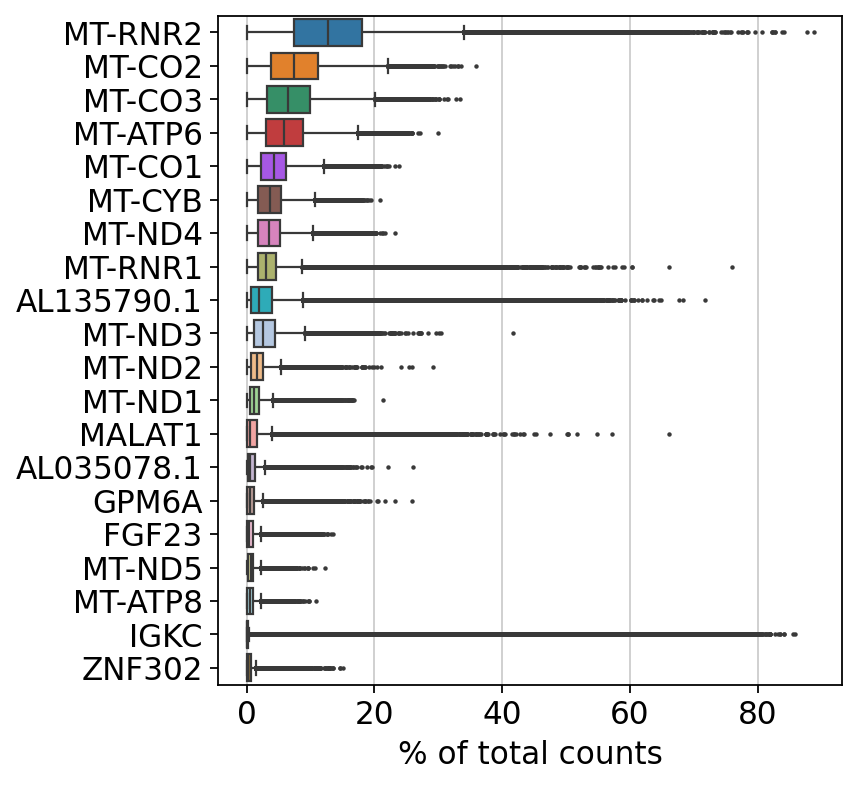

In [15]:
sc.pl.highest_expr_genes(adata_concat,n_top=20)

# Quality Control

filtered out 1369360 cells that have less than 200 genes expressed
filtered out 8978 genes that are detected in less than 3 cells


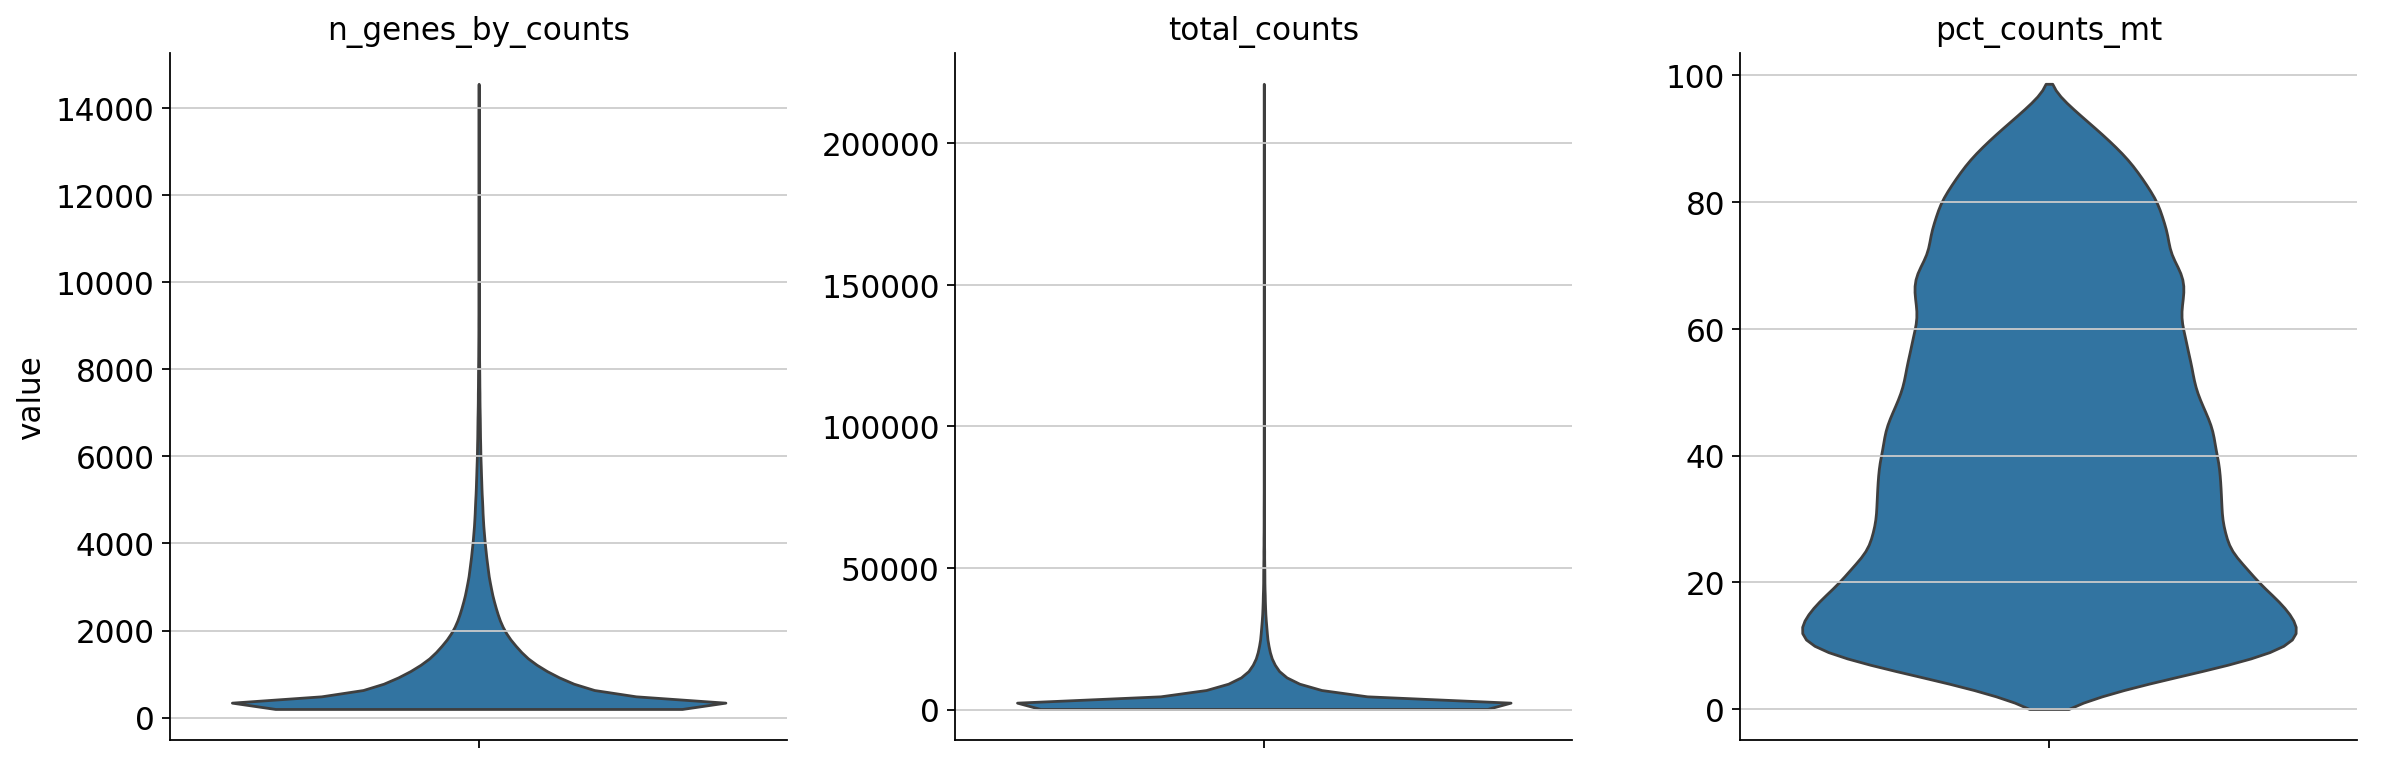

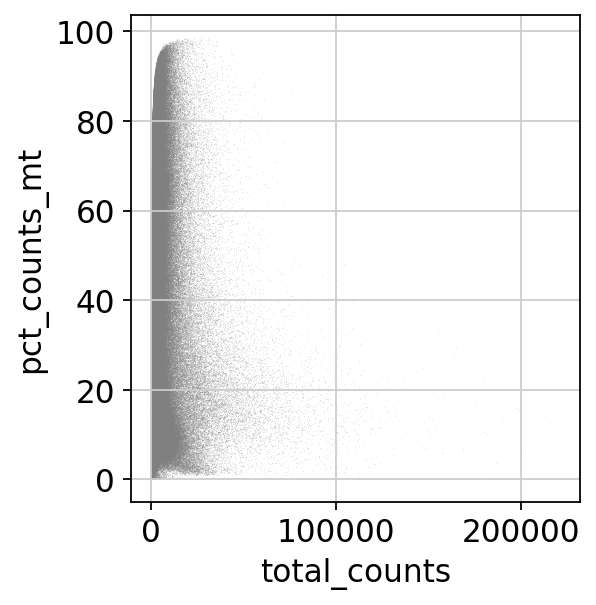

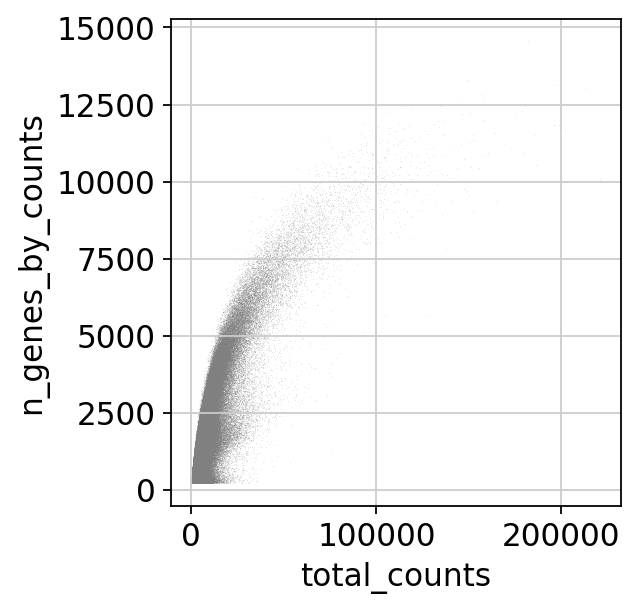

normalizing counts per cell
    finished (0:00:15)
extracting highly variable genes
    finished (0:00:16)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


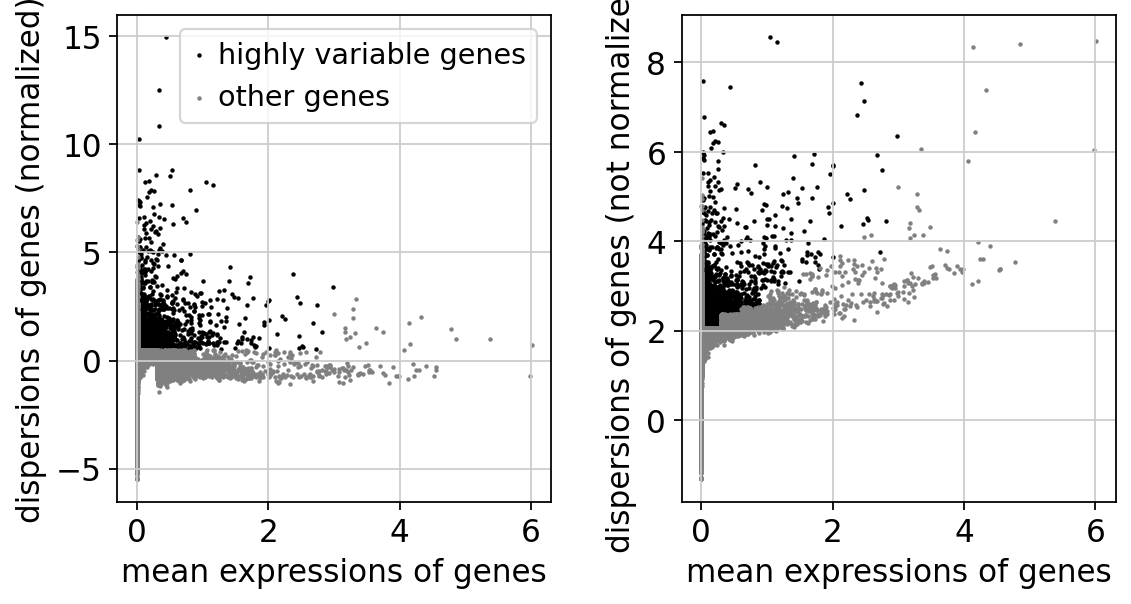

regressing out ['total_counts', 'pct_counts_mt']


/home/dimitris/Workspace/miniconda/envs/sc_analysis/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:729: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


    sparse input is densified and may lead to high memory use


/home/dimitris/Workspace/miniconda/envs/sc_analysis/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:667: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 1, 'A', False, aligned=True), Array(float64, 2, 'C', False, aligned=True))
  data[i] -= regressor[i] @ coeff
/home/dimitris/Workspace/miniconda/envs/sc_analysis/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:667: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 1, 'A', False, aligned=True), Array(float64, 2, 'C', False, aligned=True))
  data[i] -= regressor[i] @ coeff


    finished (0:00:25)
computing PCA
    with n_comps=50
    finished (0:04:01)


In [16]:
# mitochondrial genes
adata_concat.var["mt"] = adata_concat.var_names.str.startswith("MT-")
# ribosomal genes
adata_concat.var["ribo"] = adata_concat.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes.
adata_concat.var["hb"] = adata_concat.var_names.str.contains(("^HB[^(P)]"))
sc.pp.calculate_qc_metrics(
    adata_concat, qc_vars=["mt", "ribo", "hb"], inplace=True, percent_top=[20], log1p=True
)

sc.pp.filter_cells(adata_concat, min_genes=200)
sc.pp.filter_genes(adata_concat, min_cells=3)

adata_concat.var["mt"] = adata_concat.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(
    adata_concat, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True
)

sc.pl.violin(
    adata_concat,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
    stripplot=False
)

sc.pl.scatter(adata_concat, x="total_counts", y="pct_counts_mt")
sc.pl.scatter(adata_concat, x="total_counts", y="n_genes_by_counts")

adata_concat = adata_concat[adata_concat.obs.n_genes_by_counts < 2500, :]
adata_concat = adata_concat[adata_concat.obs.pct_counts_mt < 15, :].copy()

sc.pp.normalize_total(adata_concat, target_sum=1e4)

sc.pp.log1p(adata_concat)

sc.pp.highly_variable_genes(adata_concat, min_mean=0.0125, max_mean=3, min_disp=0.5)

sc.pl.highly_variable_genes(adata_concat)

adata_concat.raw = adata_concat

adata_concat = adata_concat[:, adata_concat.var.highly_variable]

sc.pp.regress_out(adata_concat, ["total_counts", "pct_counts_mt"])

sc.pp.scale(adata_concat, max_value=10)

sc.tl.pca(adata_concat, svd_solver="arpack")

In [17]:
adata_concat

AnnData object with n_obs × n_vars = 73920 × 6892
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'log_nCount_RNA', 'percent_mt', 'pcmito_inrange', 'percent_rb', 'pcribo_inrange', 'percent_st', 'min_features', 'min_counts', 'timepoint', 'site_of_biopsy', 'collection_method', 'tumor_type', 'patient_id', 'cohort', 'age', 'sex', 'bmi', 'comorbidities', 'cancer_family_history', 'clinical_trials', 'ecog_ps_at_time_of_collection', 'smoking', 'date_of_diagnosis', 'histological_type', 'histological_variants', 'grade_of_differentiation', 'tumor_size', 'tumor_location', 'metastatic_diagnosis', 'location_of_metastasis', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts'

# Clustering

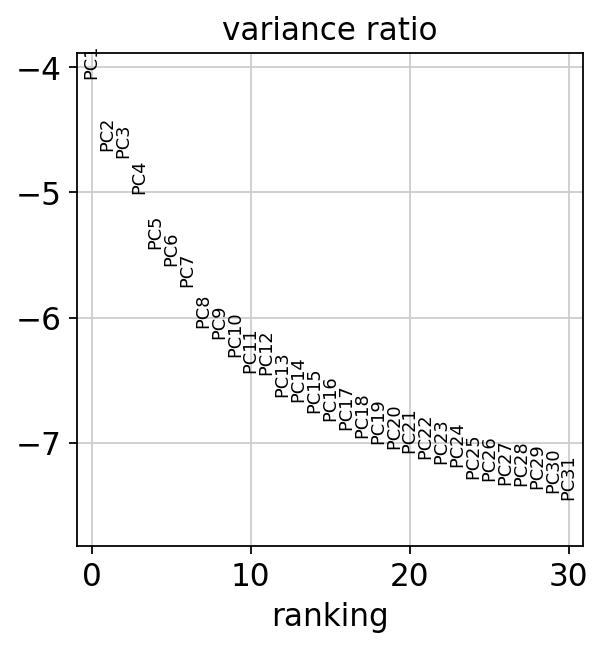

computing neighbors
    using 'X_pca' with n_pcs = 40
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:01:16)
10
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:01:42)
11


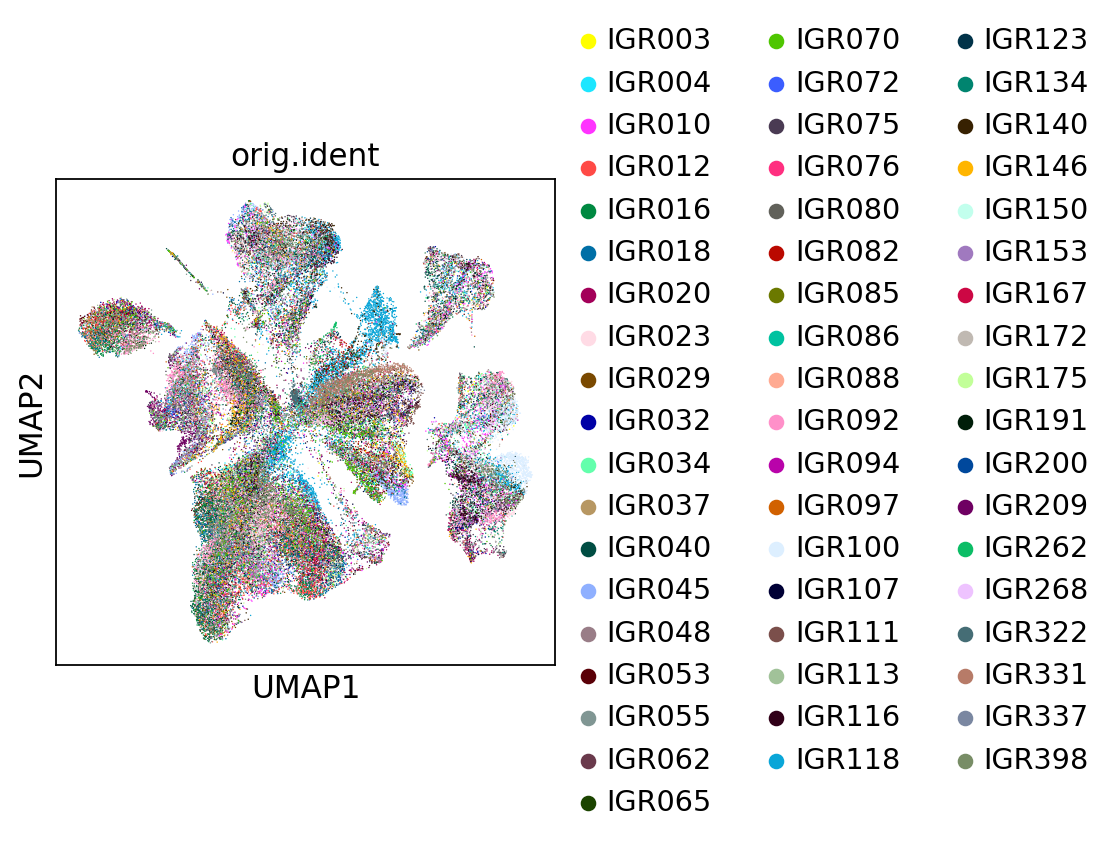

In [18]:
sc.pl.pca_variance_ratio(adata_concat, log=True)
sc.pp.neighbors(adata_concat, n_neighbors=10, n_pcs=40)
print(10)
sc.tl.umap(adata_concat)
print(11)
sc.pl.umap(adata_concat, color=['orig.ident'])

# Integration

1
computing batch balanced neighbors
	finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:03:06)
2
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:03:59)
3


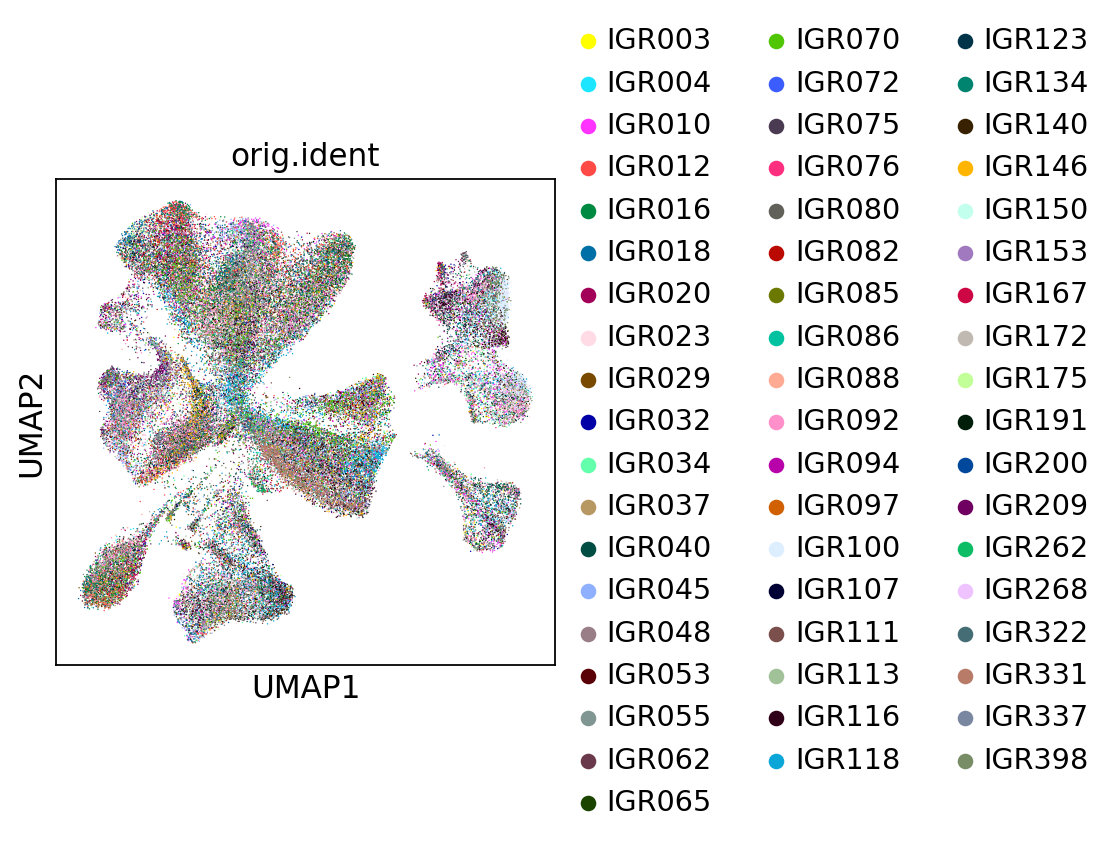

4
running Leiden clustering


/tmp/ipykernel_221893/1816340051.py:8: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_concat,resolution = 0.5)


    finished: found 13 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:17:42)
5


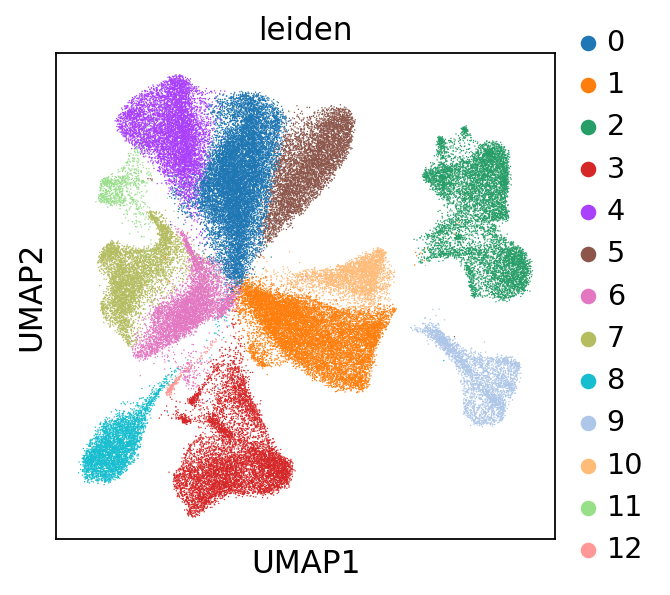

In [19]:
print(1)
sc.external.pp.bbknn(adata_concat, batch_key='orig.ident')  # running bbknn 1.3.6
print(2)
sc.tl.umap(adata_concat)
print(3)
sc.pl.umap(adata_concat, color=['orig.ident'])
print(4)
sc.tl.leiden(adata_concat,resolution = 0.5)
print(5)
sc.pl.umap(adata_concat, color=['leiden'])

# Write results

In [26]:
adata_concat.obs = adata_concat.obs.astype({"patient_id":str,"tumor_size":str})
results_file ='/home/dimitris/Workspace/crc/data/integrated_crc.h5ad'

adata_concat

# adata_concat.obs = adata_concat.obs.drop('ecog_ps_at_time_of_collection',axis =1 )
# adata_concat.obs = adata_concat.obs.drop('smoking',axis =1 )
adata_concat.write(results_file)

# Read integrated anndata object

In [1]:
import scanpy as sc
import scvi
import numpy as np
import pandas as pd
import anndata as ad
import glob
import seaborn as sns
from scipy.stats import median_abs_deviation
sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()
sc.settings.set_figure_params(dpi=80, facecolor='white')

results_file ='/home/dimitris/Workspace/crc/data/integrated_crc.h5ad'

adata_concat = sc.read(results_file)

# Annotation

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:44)


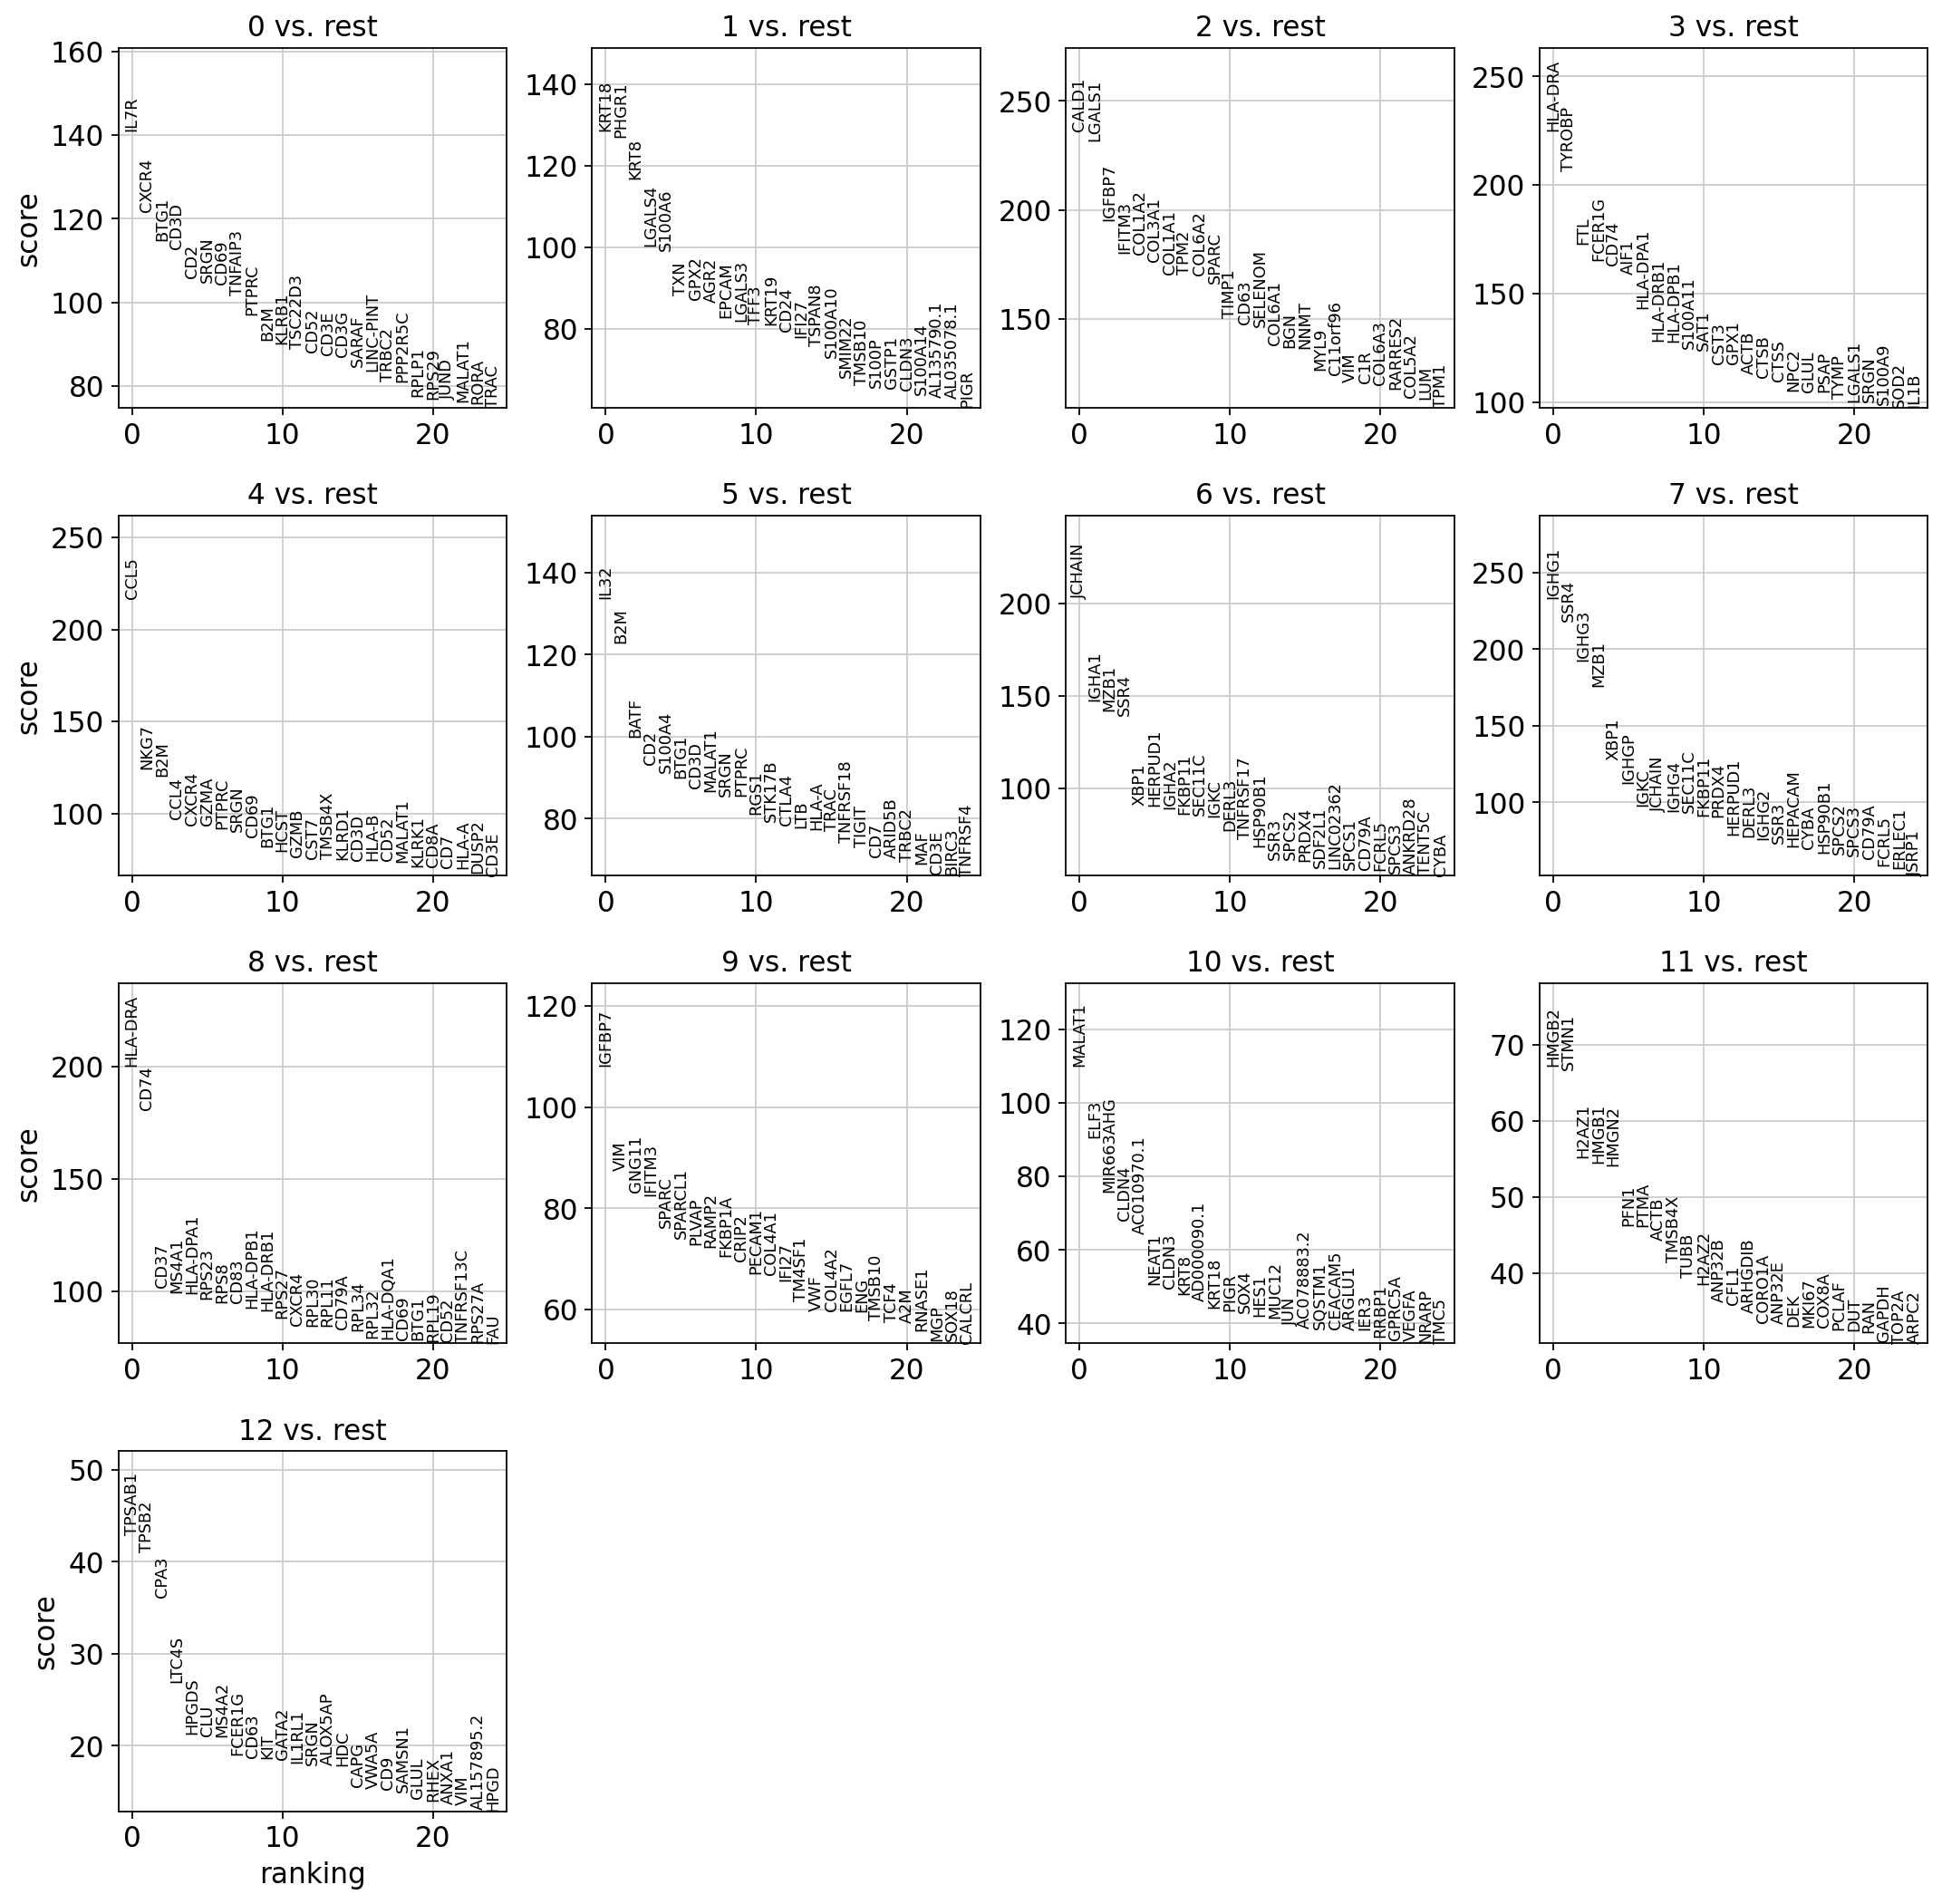

In [2]:
sc.tl.rank_genes_groups(adata_concat, 'leiden', method='t-test')
sc.pl.rank_genes_groups(adata_concat, n_genes=25, sharey=False)

In [3]:
# Get top markers for each cluster
markers = {cluster: sc.get.rank_genes_groups_df(adata_concat, group=cluster, log2fc_min=0.5).head(15).names.tolist()  for cluster in adata_concat.obs['leiden'].cat.categories}

for key, genes in markers.items():
    print(f"{key}:{', '.join(genes)}")

0:IL7R, CXCR4, BTG1, CD3D, CD2, SRGN, CD69, TNFAIP3, PTPRC, B2M, KLRB1, TSC22D3, CD52, CD3E, CD3G
1:KRT18, PHGR1, KRT8, LGALS4, S100A6, TXN, GPX2, AGR2, EPCAM, LGALS3, TFF3, KRT19, CD24, IFI27, TSPAN8
2:CALD1, LGALS1, IGFBP7, IFITM3, COL1A2, COL3A1, COL1A1, TPM2, COL6A2, SPARC, TIMP1, CD63, SELENOM, COL6A1, BGN
3:HLA-DRA, TYROBP, FTL, FCER1G, CD74, AIF1, HLA-DPA1, HLA-DRB1, HLA-DPB1, S100A11, SAT1, CST3, GPX1, ACTB, CTSB
4:CCL5, NKG7, B2M, CCL4, CXCR4, GZMA, PTPRC, SRGN, CD69, BTG1, HCST, GZMB, CST7, TMSB4X, KLRD1
5:IL32, B2M, BATF, CD2, S100A4, BTG1, CD3D, MALAT1, SRGN, PTPRC, RGS1, STK17B, CTLA4, LTB, HLA-A
6:JCHAIN, IGHA1, MZB1, SSR4, XBP1, HERPUD1, IGHA2, FKBP11, SEC11C, IGKC, DERL3, TNFRSF17, HSP90B1, SSR3, SPCS2
7:IGHG1, SSR4, IGHG3, MZB1, XBP1, IGHGP, IGKC, JCHAIN, IGHG4, SEC11C, FKBP11, PRDX4, HERPUD1, DERL3, IGHG2
8:HLA-DRA, CD74, CD37, MS4A1, HLA-DPA1, RPS23, RPS8, CD83, HLA-DPB1, HLA-DRB1, RPS27, CXCR4, RPL30, RPL11, CD79A
9:IGFBP7, VIM, GNG11, IFITM3, SPARC, SPARCL1, PLVAP,

In [4]:
# Get a list of all cluster names
clusters = adata_concat.obs['leiden'].cat.categories
all_de_dfs = []

for cluster in clusters:
    # Get ALL genes for this cluster
    de_df = sc.get.rank_genes_groups_df(adata_concat, group=cluster)
    
    # Apply filters and make a proper copy
    filtered_df = de_df[
        (de_df['logfoldchanges'].abs() > 0.5) & 
        (de_df['pvals_adj'] < 0.05)
    ].copy()
    
    # Now safely add the temporary column
    filtered_df['abs_log2fc'] = filtered_df['logfoldchanges'].abs()
    
    # Sort by absolute log2FC (descending) and p-value (ascending)
    filtered_df = filtered_df.sort_values(
        ['abs_log2fc', 'pvals_adj'], 
        ascending=[False, True]
    )
    
    # Take top N genes
    top_n = 50
    top_genes = filtered_df.head(top_n).drop('abs_log2fc', axis=1)
    top_genes['cluster'] = cluster
    
    all_de_dfs.append(top_genes)

# Combine all results
final_top_genes = pd.concat(all_de_dfs, ignore_index=True)
final_top_genes.rename(columns = {'logfoldchanges':'log2fc','names':'gene'},inplace = True)

final_top_genes.to_csv('/home/dimitris/crc_markers.csv',index = False)

In [5]:
# sampled_adata = sc.pp.subsample(adata_concat, n_obs=10000, copy=True)
# sampled_adata.write('/home/dimitris/sampled_adata_crc.h5ad')

In [5]:
reference_adata = sc.read('/home/dimitris/Workspace/crc/data/references/crc_all_cells.h5ad')

In [6]:
reference_adata = reference_adata[reference_adata.obs['disease'] == 'colon adenocarcinoma', :]
reference_adata = sc.pp.subsample(reference_adata, n_obs=20000, copy=True)

In [7]:
import mygene
gene_symbols = adata_concat.var_names.tolist()
# Create mygene client
mg = mygene.MyGeneInfo()

# Query for mapping (specify species if needed)
mapping_results = mg.querymany(gene_symbols, 
                              scopes='symbol', 
                              fields='ensembl.gene', 
                              species='human',  # Change to your species
                              returnall=True)

# Create mapping dictionary
symbol_to_ensembl = {}
for result in mapping_results['out']:
    if 'ensembl' in result:
        # Take the first Ensembl ID if multiple
        if isinstance(result['ensembl'], list):
            ensembl_id = result['ensembl'][0]['gene']
        else:
            ensembl_id = result['ensembl']['gene']
        symbol_to_ensembl[result['query']] = ensembl_id

print(f"Successfully mapped {len(symbol_to_ensembl)} genes")

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
198 input query terms found dup hits:	[('TNFRSF14-AS1', 3), ('GBP1P1', 2), ('EMBP1', 2), ('SEC22B4P', 2), ('RNVU1-30', 2), ('CRYZL2P', 2),
611 input query terms found no hit:	['AL669831.1', 'AL390719.2', 'AL162741.1', 'AL139246.5', 'AL139246.3', 'AL034417.4', 'AL021155.5', '


Successfully mapped 6264 genes


In [8]:
# Create new var_names with Ensembl IDs
new_var_names = []
unmapped_genes = []

for symbol in adata_concat.var_names:
    if symbol in symbol_to_ensembl:
        new_var_names.append(symbol_to_ensembl[symbol])
    else:
        unmapped_genes.append(symbol)
        # Keep original symbol for unmapped genes, or handle as needed
        new_var_names.append(symbol)

print(f"Could not map {len(unmapped_genes)} genes: {unmapped_genes[:10]}")

# Update the var_names
adata_concat.var_names = new_var_names

# Remove duplicate genes if any
import pandas as pd
adata_concat.var_names_make_unique()

Could not map 628 genes: ['AL669831.1', 'AL390719.2', 'AL162741.1', 'AL139246.5', 'AL139246.3', 'AL034417.4', 'AL021155.5', 'AL451042.2', 'AL109627.1', 'AL137802.2']


In [9]:
adata_concat.obs['cell_type'] = 'Unknown'

# Combine the reference and query datasets
combined_adata = ad.concat(
    [reference_adata, adata_concat],
    join='inner', # Use only genes common to both datasets
    label='dataset_origin',
    keys=['reference', 'query'],
    index_unique='_' # Makes unique cell indices
)

In [16]:
combined_adata.X

array(<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 151093782 stored elements and shape (93920, 2000)>, dtype=object)

In [11]:
# Select highly variable genes common to both batches
sc.pp.highly_variable_genes(
    combined_adata,
    n_top_genes=2000,
    # flavor='seurat_v3',
    batch_key='dataset_origin', # Important for multi-dataset integration
    subset=True
)

extracting highly variable genes
    finished (0:02:32)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


In [12]:
scvi.model.SCVI.setup_anndata(combined_adata, batch_key='dataset_origin')

/home/dimitris/Workspace/miniconda/envs/sc_analysis/lib/python3.13/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.X does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


In [14]:
vae = scvi.model.SCVI(combined_adata)
vae.train(max_epochs=1000, early_stopping=True) # Use early stopping for efficiency

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
/home/dimitris/Workspace/miniconda/envs/sc_analysis/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
/home/dimitris/Workspace/miniconda/envs/sc_analysis/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Training:   0%|          | 0/1000 [00:00<?, ?it/s]

Exception raised during training. <class 'NameError'> Expected parameter loc (Tensor of shape (128, 10)) of distribution Normal(loc: torch.Size([128, 10]), scale: torch.Size([128, 10])) to satisfy the constraint Real(), but found invalid values:
tensor([[nan, nan, nan,  ..., nan, nan, nan],
        [nan, nan, nan,  ..., nan, nan, nan],
        [nan, nan, nan,  ..., nan, nan, nan],
        ...,
        [nan, nan, nan,  ..., nan, nan, nan],
        [nan, nan, nan,  ..., nan, nan, nan],
        [nan, nan, nan,  ..., nan, nan, nan]], grad_fn=<AddmmBackward0>)


ValueError: Expected parameter loc (Tensor of shape (128, 10)) of distribution Normal(loc: torch.Size([128, 10]), scale: torch.Size([128, 10])) to satisfy the constraint Real(), but found invalid values:
tensor([[nan, nan, nan,  ..., nan, nan, nan],
        [nan, nan, nan,  ..., nan, nan, nan],
        [nan, nan, nan,  ..., nan, nan, nan],
        ...,
        [nan, nan, nan,  ..., nan, nan, nan],
        [nan, nan, nan,  ..., nan, nan, nan],
        [nan, nan, nan,  ..., nan, nan, nan]], grad_fn=<AddmmBackward0>)

In [13]:
# Setup and train scANVI for label transfer
# First, create a new label column in the combined data, marking reference labels and 'Unknown' for query
combined_adata.obs['celltype_scanvi'] = 'Unknown'
ref_idx = combined_adata.obs['dataset_origin'] == 'reference'
combined_adata.obs.loc[ref_idx, 'celltype_scanvi'] = combined_adata.obs.loc[ref_idx, 'original_cell_type_column']

# Create the scANVI model from the pre-trained scVI model
lvae = scvi.model.SCANVI.from_scvi_model(
    vae,
    adata=combined_adata,
    labels_key='celltype_scanvi',
    unlabeled_category='Unknown',
)
lvae.train(max_epochs=1000, n_samples_per_label=100)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
/home/dimitris/Workspace/miniconda/envs/sc_analysis/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
/home/dimitris/Workspace/miniconda/envs/sc_analysis/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Training:   0%|          | 0/1000 [00:00<?, ?it/s]

Exception raised during training. <class 'NameError'> Expected parameter loc (Tensor of shape (128, 10)) of distribution Normal(loc: torch.Size([128, 10]), scale: torch.Size([128, 10])) to satisfy the constraint Real(), but found invalid values:
tensor([[nan, nan, nan,  ..., nan, nan, nan],
        [nan, nan, nan,  ..., nan, nan, nan],
        [nan, nan, nan,  ..., nan, nan, nan],
        ...,
        [nan, nan, nan,  ..., nan, nan, nan],
        [nan, nan, nan,  ..., nan, nan, nan],
        [nan, nan, nan,  ..., nan, nan, nan]], grad_fn=<AddmmBackward0>)


ValueError: Expected parameter loc (Tensor of shape (128, 10)) of distribution Normal(loc: torch.Size([128, 10]), scale: torch.Size([128, 10])) to satisfy the constraint Real(), but found invalid values:
tensor([[nan, nan, nan,  ..., nan, nan, nan],
        [nan, nan, nan,  ..., nan, nan, nan],
        [nan, nan, nan,  ..., nan, nan, nan],
        ...,
        [nan, nan, nan,  ..., nan, nan, nan],
        [nan, nan, nan,  ..., nan, nan, nan],
        [nan, nan, nan,  ..., nan, nan, nan]], grad_fn=<AddmmBackward0>)

In [35]:
# Get the predicted cell types for all cells
combined_adata.obs['transferred_annotations'] = lvae.predict(combined_adata)

# Extract the predictions for the query cells only and save them back to the original query object
query_mask = combined_adata.obs['dataset_origin'] == 'query'
query_cell_predictions = combined_adata.obs[query_mask]['transferred_annotations']
query_adata.obs['transferred_annotations'] = query_cell_predictions

# (Optional) Get a joint latent representation for visualization
combined_adata.obsm['X_scANVI'] = lvae.get_latent_representation(combined_adata)

# You can now use this embedding to create a UMAP, for example
sc.pp.neighbors(combined_adata, use_rep='X_scANVI')
sc.tl.umap(combined_adata)
sc.pl.umap(combined_adata, color=['transferred_annotations', 'dataset_origin'])

NameError: name 'lvae' is not defined

In [ ]:
# Results taken from http://xteam.xbio.top/ACT/

# Order	Cluster	Cell.Type	Padj	whg.p	gsea.p	Over.Markers.whg	Over.Markers.gsea	whg.overlap	gsea.overlap
# 1	0	Effector memory CD8-positive, alpha-beta T cell	1.71587573323279e-22	1.14391715548853e-23	NA	4/44	0/1	IL7R,CXCR4,CD69,PTPRC	
# 1	1	Luminal cell	1.99767354620132e-27	1.08569214467463e-29	NA	4/45	6/271	KRT18,KRT8,AGR2,EPCAM	KRT18,KRT8,S100A6,AGR2,EPCAM,LGALS3
# 1	10	Cholangiocyte	1.35259047235233e-08	7.35103517582785e-11	NA	4/36	5/130	ELF3,CLDN4,KRT8,KRT18	ELF3,CLDN4,CLDN3,KRT8,KRT18
# 1	11	Transit amplifying cell	6.11500481153791e-12	3.32337218018364e-14	NA	2/25	7/404	HMGB2,STMN1	HMGB2,STMN1,H2AZ1,HMGB1,HMGN2,PTMA,TUBB
# 1	12	Mast cell	8.4784385224924e-66	4.60784702309369e-68	NA	9/61	10/468	TPSAB1,TPSB2,CPA3,LTC4S,HPGDS,CLU,MS4A2,CD63,KIT	TPSAB1,TPSB2,CPA3,LTC4S,HPGDS,CLU,MS4A2,FCER1G,CD63,KIT
# 1	2	Cancer-associated fibroblast	9.63001295227526e-18	1.04674053829079e-19	NA	5/25	3/213	COL1A2,COL3A1,COL1A1,COL6A2,SPARC	COL1A2,COL3A1,COL1A1
# 1	3	Dendritic cell	2.9587385583911e-32	1.60801008608212e-34	NA	8/143	10/582	HLA-DRA,TYROBP,FTL,CD74,AIF1,HLA-DPA1,HLA-DRB1,HLA-DPB1	HLA-DRA,TYROBP,FTL,FCER1G,CD74,AIF1,HLA-DPA1,HLA-DRB1,HLA-DPB1,S100A11
# 1	4	Effector memory CD8-positive, alpha-beta T cell	1.39969018141594e-42	4.66563393805312e-44	NA	7/44	0/1	CCL5,NKG7,CCL4,CXCR4,GZMA,PTPRC,CD69	
# 1	5	Mature NK T cell	1.68751629338242e-06	1.12501086225495e-07	NA	3/39	9/299	IL32,CD2,PTPRC	IL32,B2M,CD2,S100A4,BTG1,CD3D,MALAT1,SRGN,PTPRC
# 1	6	Plasma cell	2.00907813866652e-57	1.09189029275354e-59	NA	9/64	10/342	JCHAIN,IGHA1,MZB1,SSR4,XBP1,IGHA2,FKBP11,SEC11C,IGKC	JCHAIN,IGHA1,MZB1,SSR4,XBP1,HERPUD1,IGHA2,FKBP11,SEC11C,IGKC
# 1	7	Plasma cell	6.20801201718058e-59	3.37391957455467e-61	NA	10/64	10/342	IGHG1,SSR4,IGHG3,MZB1,XBP1,IGHGP,IGKC,JCHAIN,IGHG4,SEC11C	IGHG1,SSR4,IGHG3,MZB1,XBP1,IGHGP,IGKC,JCHAIN,IGHG4,SEC11C
# 1	8	Dendritic cell	1.04336899562231e-28	5.67048367186033e-31	NA	6/143	8/582	HLA-DRA,CD74,HLA-DPA1,CD83,HLA-DPB1,HLA-DRB1	HLA-DRA,CD74,HLA-DPA1,RPS23,RPS8,CD83,HLA-DPB1,HLA-DRB1
# 1	9	Endothelial cell	1.01956516898828e-12	5.54111504884937e-15	NA	8/466	10/634	IGFBP7,VIM,GNG11,SPARC,SPARCL1,PLVAP,RAMP2,FKBP1A	IGFBP7,VIM,GNG11,IFITM3,SPARC,SPARCL1,PLVAP,RAMP2,FKBP1A,CRIP2

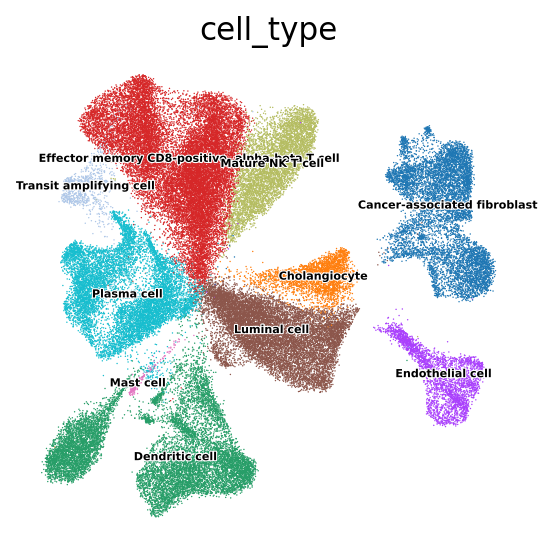

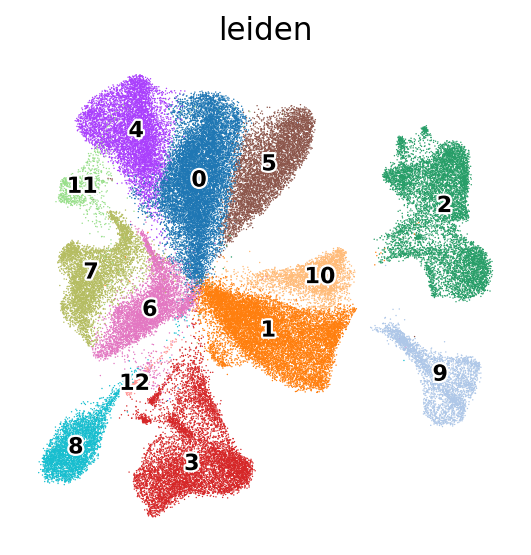

In [5]:
# taken from http://xteam.xbio.top/ACT/ResultAction.action?jobID=20240628063549UAWQVFE7YRSQ15
cluster2annotation = {
    "0": "Effector memory CD8-positive, alpha-beta T cell",
    "1": "Luminal cell", 
    "2": "Cancer-associated fibroblast",
    "3": "Dendritic cell",
    "4": "Effector memory CD8-positive, alpha-beta T cell",
    "5": "Mature NK T cell",
    "6": "Plasma cell",
    "7": "Plasma cell",
    "8": "Dendritic cell",
    "9": "Endothelial cell",
    "10": "Cholangiocyte",
    "11": "Transit amplifying cell",
    "12": "Mast cell"
}


adata_concat.obs["cell_type"] = adata_concat.obs["leiden"].map(cluster2annotation).astype("category")

sc.pl.umap(
    adata_concat,
    color="cell_type",
    legend_loc="on data",
    frameon=False,
    legend_fontsize=5,
    legend_fontoutline=1,
)
sc.pl.umap(
    adata_concat,
    color="leiden",
    legend_loc="on data",
    frameon=False,
    legend_fontsize=10,
    legend_fontoutline=2,
)

In [7]:
adata_concat.obs = adata_concat.obs.astype({"patient_id":str,"tumor_size":str})
results_file ='/home/dimitris/Workspace/crc/data/integrated_crc.h5ad'
adata_concat.write(results_file)